# 01 — Data Hub: Weekly Universe, Prices, Macro & Alternative Data

## Purpose of this notebook

This is the foundation of the new project. Everything downstream — signals, regime detection,
the optimizer, and the ML stack — depends entirely on this notebook being clean, correct,
and reproducible.

This notebook builds a **weekly** data pipeline (Friday close) for a 35+ ETF universe,
downloads macro data from FRED, fetches the VIX term structure, and sets up Google Trends
as a free alternative data source.

## Design decisions vs the old project

| Decision | Old project | This project | Why |
|---|---|---|---|
| Rebalancing frequency | Monthly | **Weekly (W-FRI)** | Captures short-term reversal signal |
| ETF universe | 8 ETFs | **35+ ETFs** | Broader diversification, more signal |
| Macro data | None | **FRED API** | Regime conditioning layer |
| Alt data | None | **Google Trends, VIX term structure** | Free edge not available at $50B AUM |
| Covariance inputs | Monthly returns | **Weekly returns + daily GARCH vol** | More responsive risk model |

## Files this notebook creates

- `data/processed/weekly_prices.csv` — Friday adjusted close prices
- `data/processed/weekly_returns.csv` — weekly log returns
- `data/processed/daily_prices.csv` — daily adjusted close (for GARCH vol in risk model)
- `data/processed/macro_weekly.csv` — FRED macro indicators, resampled to weekly
- `data/processed/vix_term_structure.csv` — VIX spot + VIX3M + term structure slope
- `data/processed/google_trends.csv` — weekly fear/sentiment signals
- `data/processed/data_quality_report.csv` — completeness, gaps, and start dates per ETF


## 1. Imports and setup

### What this section is doing
Loads all required libraries. The new additions vs the old project are:
- `fredapi` — Federal Reserve Economic Data (macro indicators, free)
- `pytrends` — Google Trends API wrapper (free, no key required)
- `arch` — GARCH volatility models (used later in risk modeling, imported here to verify install)
- `requests` — HTTP requests for VIX term structure data from Cboe

### What to expect
All imports should succeed silently. If one fails, install with `pip install <package>`.


In [19]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import warnings
from pathlib import Path
from datetime import datetime, timedelta
import time

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

if load_dotenv is not None:
    load_dotenv()

# New vs old project
try:
    from fredapi import Fred
    print("fredapi: OK")
except ImportError:
    Fred = None
    print("fredapi not installed — run: pip install fredapi")

try:
    from pytrends.request import TrendReq
    print("pytrends: OK")
except ImportError:
    TrendReq = None
    print("pytrends not installed — run: pip install pytrends")

try:
    from arch import arch_model
    print("arch (GARCH): OK")
except ImportError:
    print("arch not installed — run: pip install arch")

import requests

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def ensure_series(x, name=None):
    """Force yfinance/fred output into a clean 1D numeric Series."""
    if isinstance(x, pd.DataFrame):
        x = x.squeeze()
    x = pd.to_numeric(x, errors="coerce")
    x.index = pd.to_datetime(x.index).tz_localize(None)
    if name is not None:
        x.name = name
    return x

def flatten_columns(df):
    """Make columns a simple one-level string index so CSV output stays clean."""
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        new_cols = []
        for col in df.columns:
            if isinstance(col, tuple):
                vals = [str(v) for v in col if v not in [None, "", "Close", "Adj Close"]]
                new_cols.append(vals[-1] if vals else str(col[-1]))
            else:
                new_cols.append(str(col))
        df.columns = new_cols
    else:
        df.columns = [str(c) for c in df.columns]

    df.columns.name = None
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.index.name = "Date"
    return df

def safe_download_close(ticker, start, end=None, auto_adjust=True):
    """Download one ticker and return a clean close-price Series."""
    df = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=auto_adjust,
        progress=False,
        threads=False,
    )

    if df.empty:
        return None

    if "Close" in df.columns:
        close = df["Close"]
    elif "Adj Close" in df.columns:
        close = df["Adj Close"]
    else:
        close = df.squeeze()

    return ensure_series(close, name=ticker)

def safe_ticker_info(ticker):
    """Fetch a lightweight yfinance metadata snapshot without breaking notebook execution."""
    snapshot = {"ticker": ticker, "pull_timestamp_utc": pd.Timestamp.utcnow().isoformat()}

    try:
        tk = yf.Ticker(ticker)
    except Exception as e:
        snapshot["ticker_error"] = str(e)
        return snapshot

    try:
        info = tk.info or {}
    except Exception as e:
        info = {}
        snapshot["info_error"] = str(e)

    try:
        fast_info = dict(getattr(tk, "fast_info", {}) or {})
    except Exception as e:
        fast_info = {}
        snapshot["fast_info_error"] = str(e)

    fields = [
        "shortName",
        "longName",
        "quoteType",
        "category",
        "fundFamily",
        "currency",
        "yield",
        "dividendYield",
        "trailingAnnualDividendYield",
        "expenseRatio",
        "beta3Year",
        "threeYearAverageReturn",
        "fiveYearAverageReturn",
        "totalAssets",
        "legalType",
    ]

    for field in fields:
        snapshot[field] = info.get(field)

    for field in ["lastPrice", "previousClose", "marketCap"]:
        snapshot[f"fast_{field}"] = fast_info.get(field)

    return snapshot

def safe_dividend_history(ticker):
    """Return historical ETF distributions when Yahoo exposes them, else an empty series."""
    try:
        dividends = yf.Ticker(ticker).dividends
        if dividends is None or len(dividends) == 0:
            return pd.Series(dtype=float, name=ticker)
        return ensure_series(dividends, name=ticker)
    except Exception:
        return pd.Series(dtype=float, name=ticker)


fredapi: OK
pytrends: OK
arch (GARCH): OK


## 2. Project settings and folder structure

### What this section is doing
Defines every project-wide constant in one place so they never need to be changed
in multiple notebooks.

### Output path convention
This notebook writes its reusable outputs into `data/01_data_hub/` inside the project.
The idea is to make the research stack read like a pipeline:

- `01_data_hub.ipynb` -> `data/01_data_hub/`
- `02_layer1_alpha_signals.ipynb` -> `data/02_layer1_signals/`

### Upstream artifacts added for downstream research
In addition to prices and macro data, this notebook now saves:

- `daily_returns.csv` for cleaner risk / beta / vol work later
- explicit benchmark and proxy files so later notebooks do not assume `SPY` implicitly
- `universe_metadata.csv` with asset-class labels for neutral ranking
- cached Yahoo metadata and ETF distribution-history snapshots for more reproducible carry work
- a raw Google Trends snapshot plus pull metadata

### Key change vs old project
`START_DATE` is set to 2005 but the universe contains ETFs with different inception dates.
The data quality report at the end of this notebook documents which ETFs have full history
and which have shorter histories — downstream notebooks handle this explicitly.


In [20]:
# ── Date range ────────────────────────────────────────────────────────────────
START_DATE = "2005-01-01"
END_DATE   = None  # None = use today

# ── FRED API key ──────────────────────────────────────────────────────────────
# Security note: never hardcode API keys in notebooks or commit them to source control.
# Set FRED_API_KEY in your shell, or in a local .env file if python-dotenv is installed.
FRED_API_KEY = os.environ.get("FRED_API_KEY")
if FRED_API_KEY:
    print("FRED API key loaded from environment.")
else:
    print("FRED_API_KEY not found — FRED downloads will use the notebook's graceful fallback path.")

# ── ETF Universe (35 ETFs across 7 asset class groups) ───────────────────────
UNIVERSE = {
    # US Equity — broad
    "SPY":  "US Large Cap (S&P 500)",
    "QQQ":  "US Nasdaq 100 (Growth/Tech)",
    "IWM":  "US Small Cap (Russell 2000)",
    "VTV":  "US Large Cap Value",
    "VUG":  "US Large Cap Growth",

    # International Equity
    "EFA":  "Developed Intl Equity (ex-US)",
    "EEM":  "Emerging Market Equity",
    "VWO":  "Emerging Market Equity (alt)",
    "EWJ":  "Japan Equity",
    "VEA":  "Developed ex-US (alt)",

    # Fixed Income
    "TLT":  "US 20+ Year Treasuries",
    "IEF":  "US 7-10 Year Treasuries",
    "SHY":  "US 1-3 Year Treasuries (cash proxy)",
    "BIL":  "T-Bills (cash proxy)",
    "LQD":  "Investment Grade Corp Bonds",
    "HYG":  "High Yield Corp Bonds",
    "TIP":  "TIPS (Inflation-Linked Bonds)",
    "MBB":  "Mortgage-Backed Securities",

    # Commodities
    "GLD":  "Gold",
    "IAU":  "Gold (alt, lower cost)",
    "SLV":  "Silver",
    "DBA":  "Agriculture Commodities",
    "PDBC": "Broad Commodities",
    "USO":  "Crude Oil",

    # Real Estate
    "VNQ":  "US Real Estate (REITs)",

    # Equity Sectors (S&P GICS sectors)
    "XLK":  "Technology",
    "XLF":  "Financials",
    "XLE":  "Energy",
    "XLV":  "Healthcare",
    "XLI":  "Industrials",
    "XLU":  "Utilities",
    "XLB":  "Materials",
    "XLP":  "Consumer Staples",
    "XLY":  "Consumer Discretionary",

    # Macro / FX / Alternatives
    "UUP":  "US Dollar Index (bullish)",
}

UNIVERSE_ASSET_CLASS = {
    "SPY": "Equities",
    "QQQ": "Equities",
    "IWM": "Equities",
    "VTV": "Equities",
    "VUG": "Equities",
    "EFA": "Equities",
    "EEM": "Equities",
    "VWO": "Equities",
    "EWJ": "Equities",
    "VEA": "Equities",
    "TLT": "Bonds",
    "IEF": "Bonds",
    "SHY": "Bonds",
    "BIL": "Bonds",
    "LQD": "Bonds",
    "HYG": "Bonds",
    "TIP": "Bonds",
    "MBB": "Bonds",
    "GLD": "Commodities",
    "IAU": "Commodities",
    "SLV": "Commodities",
    "DBA": "Commodities",
    "PDBC": "Commodities",
    "USO": "Commodities",
    "VNQ": "REITs",
    "XLK": "Equities",
    "XLF": "Equities",
    "XLE": "Equities",
    "XLV": "Equities",
    "XLI": "Equities",
    "XLU": "Equities",
    "XLB": "Equities",
    "XLP": "Equities",
    "XLY": "Equities",
    "UUP": "FX",
}

PROXY_MAPPING = {
    "market_proxy": {
        "ticker": "SPY",
        "description": "US equity market proxy for beta and broad risk-on/off work",
    },
    "cash_proxy": {
        "ticker": "BIL",
        "description": "Cash / front-end rates proxy",
    },
    "short_duration_proxy": {
        "ticker": "SHY",
        "description": "Short-duration Treasury proxy",
    },
    "intermediate_duration_proxy": {
        "ticker": "IEF",
        "description": "Intermediate-duration Treasury proxy",
    },
    "duration_proxy": {
        "ticker": "TLT",
        "description": "Long-duration Treasury proxy",
    },
    "credit_proxy": {
        "ticker": "LQD",
        "description": "Investment-grade credit proxy",
    },
    "high_yield_proxy": {
        "ticker": "HYG",
        "description": "High-yield credit proxy",
    },
    "inflation_proxy": {
        "ticker": "TIP",
        "description": "Inflation-linked bond proxy",
    },
    "commodity_proxy": {
        "ticker": "PDBC",
        "description": "Broad commodity proxy",
    },
    "gold_proxy": {
        "ticker": "GLD",
        "description": "Gold proxy",
    },
    "dollar_proxy": {
        "ticker": "UUP",
        "description": "Dollar strength proxy",
    },
    "reit_proxy": {
        "ticker": "VNQ",
        "description": "Listed real-estate proxy",
    },
}

TICKERS = list(UNIVERSE.keys())
print(f"Universe: {len(TICKERS)} ETFs across 7 asset class groups")
print()
for ticker, desc in UNIVERSE.items():
    print(f"  {ticker:<6} {desc}")

# ── Folder structure ─────────────────────────────────────────────────────────
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "01_data_hub"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR  =", PROJECT_DIR.resolve())
print("DATA_DIR     =", DATA_DIR.resolve())
print("DATA_HUB_DIR =", PROCESSED_DIR.resolve())


Universe: 35 ETFs across 7 asset class groups

  SPY    US Large Cap (S&P 500)
  QQQ    US Nasdaq 100 (Growth/Tech)
  IWM    US Small Cap (Russell 2000)
  VTV    US Large Cap Value
  VUG    US Large Cap Growth
  EFA    Developed Intl Equity (ex-US)
  EEM    Emerging Market Equity
  VWO    Emerging Market Equity (alt)
  EWJ    Japan Equity
  VEA    Developed ex-US (alt)
  TLT    US 20+ Year Treasuries
  IEF    US 7-10 Year Treasuries
  SHY    US 1-3 Year Treasuries (cash proxy)
  BIL    T-Bills (cash proxy)
  LQD    Investment Grade Corp Bonds
  HYG    High Yield Corp Bonds
  TIP    TIPS (Inflation-Linked Bonds)
  MBB    Mortgage-Backed Securities
  GLD    Gold
  IAU    Gold (alt, lower cost)
  SLV    Silver
  DBA    Agriculture Commodities
  PDBC   Broad Commodities
  USO    Crude Oil
  VNQ    US Real Estate (REITs)
  XLK    Technology
  XLF    Financials
  XLE    Energy
  XLV    Healthcare
  XLI    Industrials
  XLU    Utilities
  XLB    Materials
  XLP    Consumer Staples
  XLY    Co

## 3. Download daily adjusted close prices

### What this section is doing
Downloads the full daily price history for all 35 ETFs from Yahoo Finance using `yfinance`.
We download daily data first (not weekly) because:
1. Weekly prices are derived from daily prices by taking Friday closes
2. The risk model (GARCH) needs daily data to estimate conditional volatility
3. Having daily data lets us compute intraday vol proxies and daily signal updates

### Why adjusted close
Adjusted close accounts for stock splits, dividends, and other corporate actions.
Using raw close prices would show artificial drops on ex-dividend dates that
would corrupt momentum and carry signals.

### Data quality note
Not all ETFs exist back to 2005. The download returns NaN for dates before an ETF's inception.
We handle this explicitly in Section 6 (Data Quality Report).

### What to expect
A 3-5 second download per ticker. Total ~2 minutes for 35 ETFs. The output will be
a DataFrame with one column per ETF and one row per trading day.


In [21]:
print(f"Downloading daily prices for {len(TICKERS)} ETFs from {START_DATE}...")
print("This takes 2-3 minutes. Each dot = one ETF downloaded.")
print()

raw_data = {}
failed   = []

for i, ticker in enumerate(TICKERS):
    try:
        s = safe_download_close(ticker, start=START_DATE, end=END_DATE, auto_adjust=True)

        if s is None or s.dropna().empty:
            failed.append(ticker)
            print(f"  WARN: {ticker} returned empty data")
        else:
            raw_data[ticker] = s
            print(
                f"  [{i+1:02d}/{len(TICKERS)}] {ticker}: {s.notna().sum()} days, "
                f"from {s.dropna().index.min().date()} to {s.dropna().index.max().date()}"
            )
    except Exception as e:
        failed.append(ticker)
        print(f"  ERROR: {ticker} — {e}")
    time.sleep(0.3)  # be polite to Yahoo Finance

print()
print(f"Downloaded: {len(raw_data)} ETFs   Failed: {len(failed)} ETFs")
if failed:
    print(f"Failed tickers: {failed}")


This takes 2-3 minutes. Each dot = one ETF downloaded.

  [01/35] SPY: 5351 days, from 2005-01-03 to 2026-04-10
  [02/35] QQQ: 5351 days, from 2005-01-03 to 2026-04-10
  [03/35] IWM: 5351 days, from 2005-01-03 to 2026-04-10
  [04/35] VTV: 5351 days, from 2005-01-03 to 2026-04-10
  [05/35] VUG: 5351 days, from 2005-01-03 to 2026-04-10
  [06/35] EFA: 5351 days, from 2005-01-03 to 2026-04-10
  [07/35] EEM: 5351 days, from 2005-01-03 to 2026-04-10
  [08/35] VWO: 5305 days, from 2005-03-10 to 2026-04-10
  [09/35] EWJ: 5351 days, from 2005-01-03 to 2026-04-10
  [10/35] VEA: 4707 days, from 2007-07-26 to 2026-04-10
  [11/35] TLT: 5351 days, from 2005-01-03 to 2026-04-10
  [12/35] IEF: 5351 days, from 2005-01-03 to 2026-04-10
  [13/35] SHY: 5351 days, from 2005-01-03 to 2026-04-10
  [14/35] BIL: 4747 days, from 2007-05-30 to 2026-04-10
  [15/35] LQD: 5351 days, from 2005-01-03 to 2026-04-10
  [16/35] HYG: 4781 days, from 2007-04-11 to 2026-04-10
  [17/35] TIP: 5351 days, from 2005-01-03 to 202

In [22]:
# Combine into a single DataFrame — one column per ticker
daily_prices = pd.concat(raw_data.values(), axis=1)
daily_prices = flatten_columns(daily_prices)

# Sort columns alphabetically for consistency
daily_prices = daily_prices.sort_index(axis=1)

print(f"Daily price matrix shape: {daily_prices.shape}")
print(f"Date range: {daily_prices.index.min().date()} to {daily_prices.index.max().date()}")
print(f"Trading days: {len(daily_prices)}")
print()

print("Missing data per ETF (count of NaN days):")
missing = daily_prices.isna().sum()
print(missing[missing > 0].to_string())

# Save raw daily prices and daily log returns for downstream risk work
daily_path = PROCESSED_DIR / "daily_prices.csv"
daily_prices.to_csv(daily_path)

daily_returns = np.log(daily_prices / daily_prices.shift(1))
daily_returns = daily_returns.dropna(how="all")
daily_returns = flatten_columns(daily_returns)
daily_returns_path = PROCESSED_DIR / "daily_returns.csv"
daily_returns.to_csv(daily_returns_path)

print(f"\nSaved daily prices: {daily_path}")
print(f"Saved daily returns: {daily_returns_path}")


Daily price matrix shape: (5351, 35)
Date range: 2005-01-03 to 2026-04-10
Trading days: 5351

Missing data per ETF (count of NaN days):
BIL      604
DBA      505
HYG      570
IAU       18
MBB      553
PDBC    2480
SLV      332
USO      319
UUP      542
VEA      644
VWO       46

Saved daily prices: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data2/processed/daily_prices.csv


## 4. Resample to weekly (Friday close) and compute log returns

### What this section is doing
Converts daily prices to weekly by taking the Friday close price using
`resample("W-FRI").last()`. This is the core frequency change vs the old project.

### Why Friday close
- Friday close is the most widely used convention for weekly systematic strategies
- Avoids Monday open gaps and Monday effect biases
- Consistent with how most AQR and Man AHL research papers define weekly returns

### Why log returns vs simple returns
Log returns (ln(P_t/P_{t-1})) are used because:
1. They are time-additive: monthly log return = sum of daily log returns
2. They have better statistical properties (closer to normal distribution)
3. They prevent negative prices in simulations
4. This is the standard at quant research firms

### Handling incomplete weeks
The last week in the dataset may be incomplete (e.g., data through Wednesday).
We drop any incomplete final week to ensure all returns represent full 5-day periods.

### What to expect
The weekly DataFrame should have roughly 1/5 the number of rows as the daily DataFrame.


In [23]:
# ── Resample to weekly Friday close ──────────────────────────────────────────
weekly_prices = daily_prices.resample("W-FRI").last()
weekly_prices = flatten_columns(weekly_prices)

# Drop any incomplete final week (same logic as old project, now weekly)
last_daily_date   = daily_prices.index.max()
last_weekly_label = weekly_prices.index.max()

# If last weekly label is ahead of last available daily data, drop it
if last_daily_date < last_weekly_label - pd.Timedelta(days=1):
    weekly_prices = weekly_prices.iloc[:-1]
    print(f"Dropped incomplete final week: {last_weekly_label.date()}")
else:
    print(f"Final week is complete: {last_weekly_label.date()}")

print(f"Weekly prices shape: {weekly_prices.shape}")
print(f"Date range: {weekly_prices.index.min().date()} to {weekly_prices.index.max().date()}")
print(f"Total weeks: {len(weekly_prices)}")


Final week is complete: 2026-04-10
Weekly prices shape: (1110, 35)
Date range: 2005-01-07 to 2026-04-10
Total weeks: 1110


In [24]:
# ── Compute weekly log returns ────────────────────────────────────────────────
weekly_returns = np.log(weekly_prices / weekly_prices.shift(1))
weekly_returns = weekly_returns.dropna(how="all")
weekly_returns = flatten_columns(weekly_returns)

print(f"Weekly returns shape: {weekly_returns.shape}")
print(f"Return date range: {weekly_returns.index.min().date()} to {weekly_returns.index.max().date()}")
print()
print("Annualized vol per ETF (sanity check — equity ETFs should be 15-25%):")
ann_vol = weekly_returns.std() * np.sqrt(52)
print(ann_vol.sort_values(ascending=False).round(3).to_string())


Weekly returns shape: (1109, 35)
Return date range: 2005-01-14 to 2026-04-10

Annualized vol per ETF (sanity check — equity ETFs should be 15-25%):
USO     0.373
SLV     0.328
XLE     0.284
XLF     0.268
VNQ     0.254
EEM     0.235
IWM     0.230
VWO     0.226
XLB     0.224
XLY     0.214
XLI     0.207
XLK     0.203
QQQ     0.199
VEA     0.199
EFA     0.193
VUG     0.189
EWJ     0.185
XLU     0.181
PDBC    0.179
SPY     0.177
VTV     0.177
IAU     0.173
GLD     0.172
DBA     0.165
XLV     0.163
TLT     0.138
XLP     0.133
HYG     0.114
LQD     0.087
UUP     0.077
IEF     0.064
TIP     0.060
MBB     0.042
SHY     0.014
BIL     0.004


In [25]:
# ── Save weekly files ────────────────────────────────────────────────────────
weekly_prices_path  = PROCESSED_DIR / "weekly_prices.csv"
weekly_returns_path = PROCESSED_DIR / "weekly_returns.csv"

weekly_prices.to_csv(weekly_prices_path)
weekly_returns.to_csv(weekly_returns_path)

print(f"Saved: {weekly_prices_path}")
print(f"Saved: {weekly_returns_path}")


Saved: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data2/processed/weekly_prices.csv
Saved: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data2/processed/weekly_returns.csv


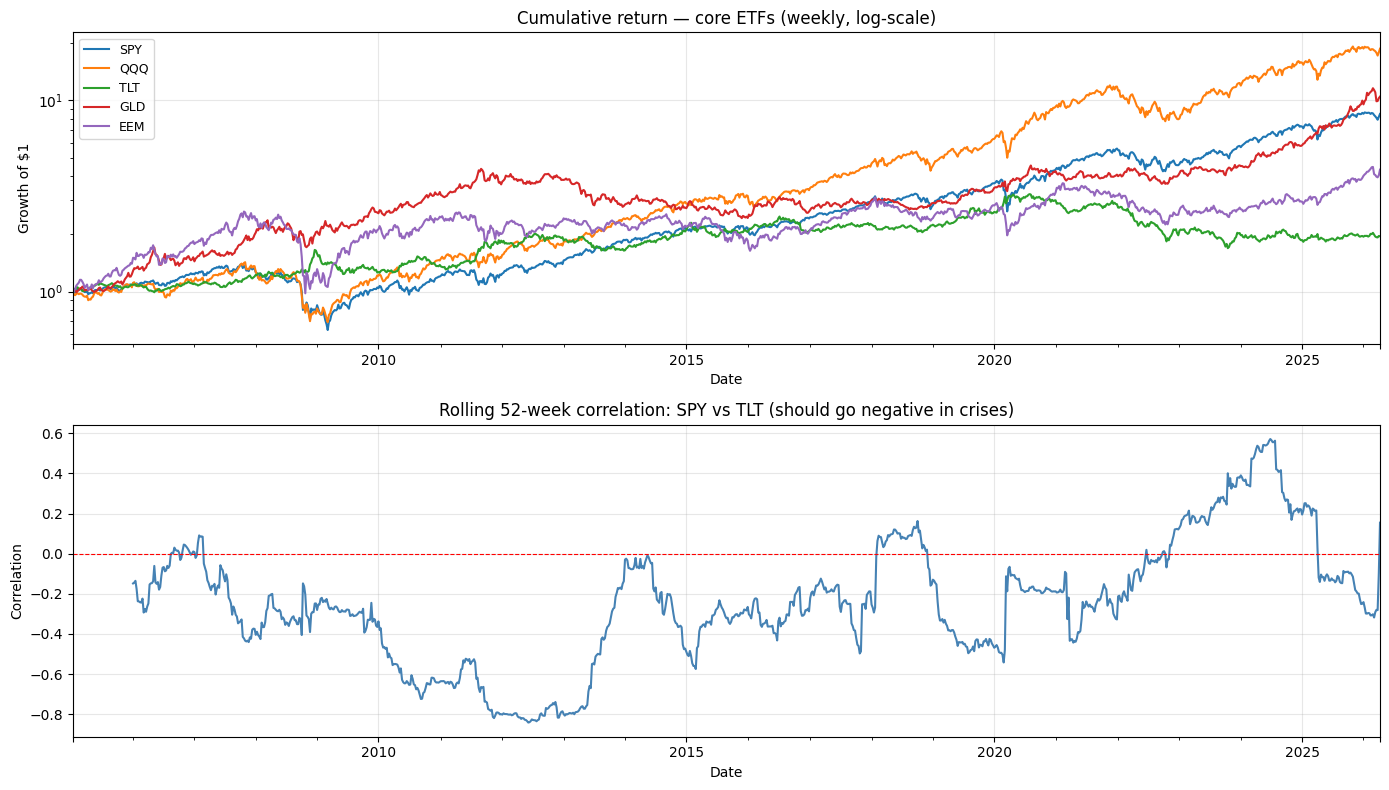

Saved sanity check chart


In [26]:
# ── Quick visual sanity check ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Equity curve of select ETFs
core_etfs = ["SPY", "QQQ", "TLT", "GLD", "EEM"]
core_etfs = [t for t in core_etfs if t in weekly_returns.columns]
cumulative = np.exp(weekly_returns[core_etfs].fillna(0).cumsum())
cumulative.plot(ax=axes[0], title="Cumulative return — core ETFs (weekly, log-scale)")
axes[0].set_yscale("log")
axes[0].set_ylabel("Growth of $1")
axes[0].legend(loc="upper left", fontsize=9)

# Rolling 52-week correlation between SPY and TLT
if "SPY" in weekly_returns.columns and "TLT" in weekly_returns.columns:
    corr_input = weekly_returns[["SPY", "TLT"]].apply(pd.to_numeric, errors="coerce").dropna()
    rolling_corr = corr_input["SPY"].rolling(52).corr(corr_input["TLT"])
    rolling_corr.plot(ax=axes[1], color="steelblue",
                      title="Rolling 52-week correlation: SPY vs TLT (should go negative in crises)")
    axes[1].axhline(0, color="red", linewidth=0.8, linestyle="--")
    axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "01_price_sanity_check.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved sanity check chart")


## 5. FRED macro data

### What this section is doing
Downloads macroeconomic indicators from the Federal Reserve Economic Data (FRED) API.
These form the **macro conditioning layer** — the signals that tell us which regime we are in.

### Why each indicator matters
| Indicator | FRED Code | Why it matters |
|---|---|---|
| Yield curve slope (10Y-2Y) | T10Y2Y | Inversion predicts recessions 12-18 months ahead |
| High-yield credit spread | BAMLH0A0HYM2 | Credit stress = risk-off regime |
| ISM Manufacturing PMI | NAPM | Above 50 = expansion; below 50 = contraction |
| Consumer Sentiment | UMCSENT | Leading indicator for consumer spending |
| Fed Funds Rate | FEDFUNDS | Interest-rate regime and policy stance |
| 3M Treasury yield | DGS3MO | Short-rate / liquidity reference for policy-tightness proxies |
| US Dollar (broad) | DTWEXBGS | Dollar strength = commodity/EM headwind |
| CPI (inflation) | CPIAUCSL | Inflation regime — drives bond/commodity tradeoffs |
| Unemployment rate | UNRATE | Business-cycle indicator |
| Chicago Fed NFCI | NFCI | Clean, reproducible liquidity / financial-conditions proxy |

### About the FRED API key
A free API key from fred.stlouisfed.org gives 100,000 API calls/day.
For security, this notebook now expects `FRED_API_KEY` in your local environment or `.env` file.
If the key is missing, the notebook skips the full FRED pull and falls back gracefully.

### What to expect
Some series are monthly while others are daily or weekly. We forward-fill them to weekly Friday frequency
so downstream notebooks can align everything on one research calendar.


In [27]:
# ── Define FRED series to download ───────────────────────────────────────────
FRED_SERIES = {
    "T10Y2Y":       "Yield Curve Slope (10Y-2Y)",
    "BAMLH0A0HYM2": "High Yield Credit Spread (OAS)",
    "NAPM":         "ISM Manufacturing PMI",
    "UMCSENT":      "Consumer Sentiment (Michigan)",
    "FEDFUNDS":     "Federal Funds Rate",
    "DGS3MO":       "3-Month Treasury Yield",
    "DTWEXBGS":     "US Dollar Index (Broad)",
    "CPIAUCSL":     "CPI (All Urban Consumers)",
    "UNRATE":       "Unemployment Rate",
    "NFCI":         "Chicago Fed National Financial Conditions Index",
}

# ── Try FRED API, fall back to yfinance proxies if needed ────────────────────
# Security hardening: the key is loaded from your local environment instead of being hardcoded.
macro_raw = {}

try:
    if Fred is None:
        raise ImportError("fredapi not installed")
    if not FRED_API_KEY:
        raise RuntimeError("FRED_API_KEY not set")
    fred = Fred(api_key=FRED_API_KEY)
    print("FRED API connected. Downloading series:")
    for series_id, description in FRED_SERIES.items():
        try:
            data = fred.get_series(series_id, observation_start=START_DATE)
            data = ensure_series(data, name=series_id)
            macro_raw[series_id] = data
            print(f"  {series_id:<20} OK  ({len(data)} observations, latest: {data.index.max().date()})")
        except Exception as e:
            print(f"  {series_id:<20} FAILED: {e}")
except Exception as e:
    print(f"FRED macro download unavailable: {e}")
    print("Falling back to yfinance proxy for key series. Set FRED_API_KEY locally for full macro coverage.")
    fallback = safe_download_close("^VIX", start=START_DATE, end=END_DATE, auto_adjust=False)
    if fallback is not None:
        macro_raw["VIX_FALLBACK"] = fallback
        print("  Downloaded VIX as fallback. This keeps the notebook runnable while FRED is unavailable.")
    else:
        print("  VIX fallback download also failed; macro_weekly will be saved as an empty placeholder.")


FRED API connected. Downloading series:
  T10Y2Y               OK  (5550 observations, latest: 2026-04-10)
  BAMLH0A0HYM2         OK  (5621 observations, latest: 2026-04-09)
  NAPM                 FAILED: Bad Request.  The series does not exist.
  UMCSENT              OK  (254 observations, latest: 2026-02-01)
  FEDFUNDS             OK  (255 observations, latest: 2026-03-01)
  DTWEXBGS             OK  (5285 observations, latest: 2026-04-03)
  CPIAUCSL             OK  (255 observations, latest: 2026-03-01)
  UNRATE               OK  (255 observations, latest: 2026-03-01)


In [28]:
# ── Combine into a weekly macro DataFrame ────────────────────────────────────
if macro_raw and not all(k == "VIX_FALLBACK" for k in macro_raw):
    macro_df = pd.concat(macro_raw.values(), axis=1)
    macro_df = flatten_columns(macro_df)

    # Resample all series to weekly (Friday) — forward fill for monthly series
    macro_weekly = macro_df.resample("W-FRI").last().ffill()

    # Align to our weekly returns date range
    macro_weekly = macro_weekly.reindex(weekly_prices.index, method="ffill")
    macro_weekly = flatten_columns(macro_weekly)

    if {"FEDFUNDS", "DGS3MO"}.issubset(macro_weekly.columns):
        macro_weekly["policy_minus_3m"] = macro_weekly["FEDFUNDS"] - macro_weekly["DGS3MO"]

    print(f"Macro weekly shape: {macro_weekly.shape}")
    print(f"Columns: {list(macro_weekly.columns)}")
    print()
    print("Latest values:")
    print(macro_weekly.iloc[-1].to_string())

    macro_path = PROCESSED_DIR / "macro_weekly.csv"
    macro_weekly.to_csv(macro_path)
    print(f"\nSaved: {macro_path}")
else:
    print("Using fallback macro data. Set FRED_API_KEY locally for full macro features.")
    macro_weekly = pd.DataFrame(index=weekly_prices.index)
    macro_weekly.index.name = "Date"
    macro_weekly.to_csv(PROCESSED_DIR / "macro_weekly.csv")


Macro weekly shape: (1110, 7)
Columns: ['T10Y2Y', 'BAMLH0A0HYM2', 'UMCSENT', 'FEDFUNDS', 'DTWEXBGS', 'CPIAUCSL', 'UNRATE']

Latest values:
T10Y2Y            0.5000
BAMLH0A0HYM2      2.9000
UMCSENT          56.6000
FEDFUNDS          3.6400
DTWEXBGS        120.6565
CPIAUCSL        330.2930
UNRATE            4.3000

Saved: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data2/processed/macro_weekly.csv


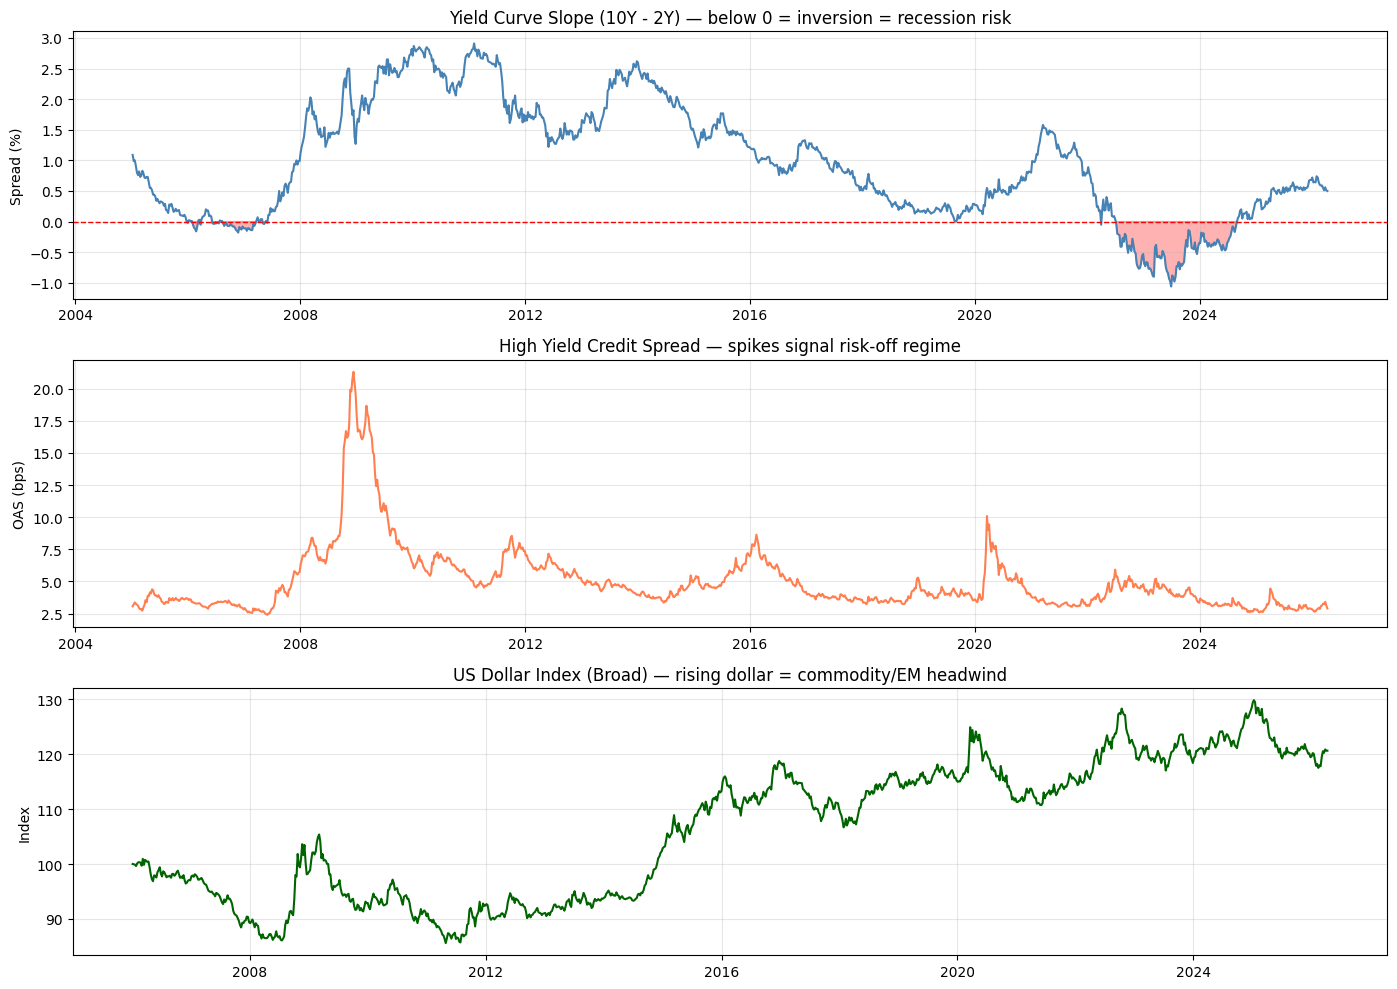

In [29]:
# ── Visualize macro regime indicators ────────────────────────────────────────
if "T10Y2Y" in macro_weekly.columns and "BAMLH0A0HYM2" in macro_weekly.columns:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Yield curve
    axes[0].plot(macro_weekly.index, macro_weekly["T10Y2Y"], color="steelblue")
    axes[0].set_title("Yield Curve Slope (10Y - 2Y) — below 0 = inversion = recession risk")
    axes[0].axhline(0, color="red", linewidth=1, linestyle="--")
    yc = pd.to_numeric(macro_weekly["T10Y2Y"], errors="coerce")
    axes[0].fill_between(
        macro_weekly.index, yc.values, np.zeros(len(yc)),
        where=(yc.values < 0), alpha=0.3, color="red", label="Inverted"
    )
    axes[0].set_ylabel("Spread (%)")

    # Credit spread
    axes[1].plot(macro_weekly.index, macro_weekly["BAMLH0A0HYM2"], color="coral")
    axes[1].set_title("High Yield Credit Spread — spikes signal risk-off regime")
    axes[1].set_ylabel("OAS (bps)")

    # Dollar
    if "DTWEXBGS" in macro_weekly.columns:
        axes[2].plot(macro_weekly.index, macro_weekly["DTWEXBGS"], color="darkgreen")
        axes[2].set_title("US Dollar Index (Broad) — rising dollar = commodity/EM headwind")
        axes[2].set_ylabel("Index")

    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / "01_macro_indicators.png", dpi=120, bbox_inches="tight")
    plt.show()


## 6. VIX term structure

### What this section is doing
Downloads VIX (1-month implied vol) and VIX3M (3-month implied vol) from Yahoo Finance.
Computes the VIX term structure slope = VIX3M - VIX.

### Why this matters
The VIX term structure slope is one of the most useful free regime signals:
- **Contango** (slope > 0, VIX3M > VIX): Normal — near-term calm, momentum-friendly
- **Flat / Backwardation** (slope ≤ 0): Stress — near-term fear exceeds long-term, reversal-friendly

It is also a carry signal: in contango, there is a positive roll yield from being short VIX futures
(short front, long back). This is the VIX term structure carry trade.

### What to expect
VIX goes from Yahoo Finance as `^VIX` and VIX3M as `^VIX3M`. Both are free.
The slope will be positive most of the time (~75% of weeks) and spike negative during crises.


In [30]:
print("Downloading VIX term structure...")

vix_spot = safe_download_close("^VIX", start=START_DATE, end=END_DATE, auto_adjust=False)
vix_3m   = safe_download_close("^VIX3M", start=START_DATE, end=END_DATE, auto_adjust=False)
vix_6m   = safe_download_close("^VIX6M", start=START_DATE, end=END_DATE, auto_adjust=False)

vix_parts = [s for s in [vix_spot, vix_3m, vix_6m] if s is not None]
if len(vix_parts) == 0:
    raise ValueError("No VIX series downloaded.")

# Combine into one DataFrame
vix_df = pd.concat(vix_parts, axis=1)
vix_df = flatten_columns(vix_df)
vix_df = vix_df.rename(columns={"^VIX": "VIX", "^VIX3M": "VIX3M", "^VIX6M": "VIX6M"})

# Resample to weekly Friday close
vix_weekly = vix_df.resample("W-FRI").last()
vix_weekly = vix_weekly.reindex(weekly_prices.index, method="ffill")
vix_weekly = flatten_columns(vix_weekly)

# Compute slope (primary signal)
vix_weekly["slope_1m_3m"] = vix_weekly["VIX3M"] - vix_weekly["VIX"]
vix_weekly["slope_1m_6m"] = vix_weekly["VIX6M"] - vix_weekly["VIX"]

# Regime flag: contango (normal) vs backwardation (stress)
vix_weekly["contango"] = (vix_weekly["slope_1m_3m"] > 0).astype(int)
vix_weekly["stress_flag"] = (vix_weekly["VIX"] > 25).astype(int)

print(f"VIX term structure shape: {vix_weekly.shape}")
print(f"\nCurrent readings:")
print(vix_weekly[["VIX", "VIX3M", "slope_1m_3m", "contango", "stress_flag"]].iloc[-1].to_string())
print(f"\nContango % of time: {vix_weekly['contango'].mean():.1%}")
print(f"High stress % of time (VIX>25): {vix_weekly['stress_flag'].mean():.1%}")

vix_path = PROCESSED_DIR / "vix_term_structure.csv"
vix_weekly.to_csv(vix_path)
print(f"\nSaved: {vix_path}")


VIX term structure shape: (1110, 7)

Current readings:
VIX            19.230000
VIX3M          21.860001
slope_1m_3m     2.630001
contango        1.000000
stress_flag     0.000000

Contango % of time: 83.2%
High stress % of time (VIX>25): 16.0%

Saved: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data2/processed/vix_term_structure.csv


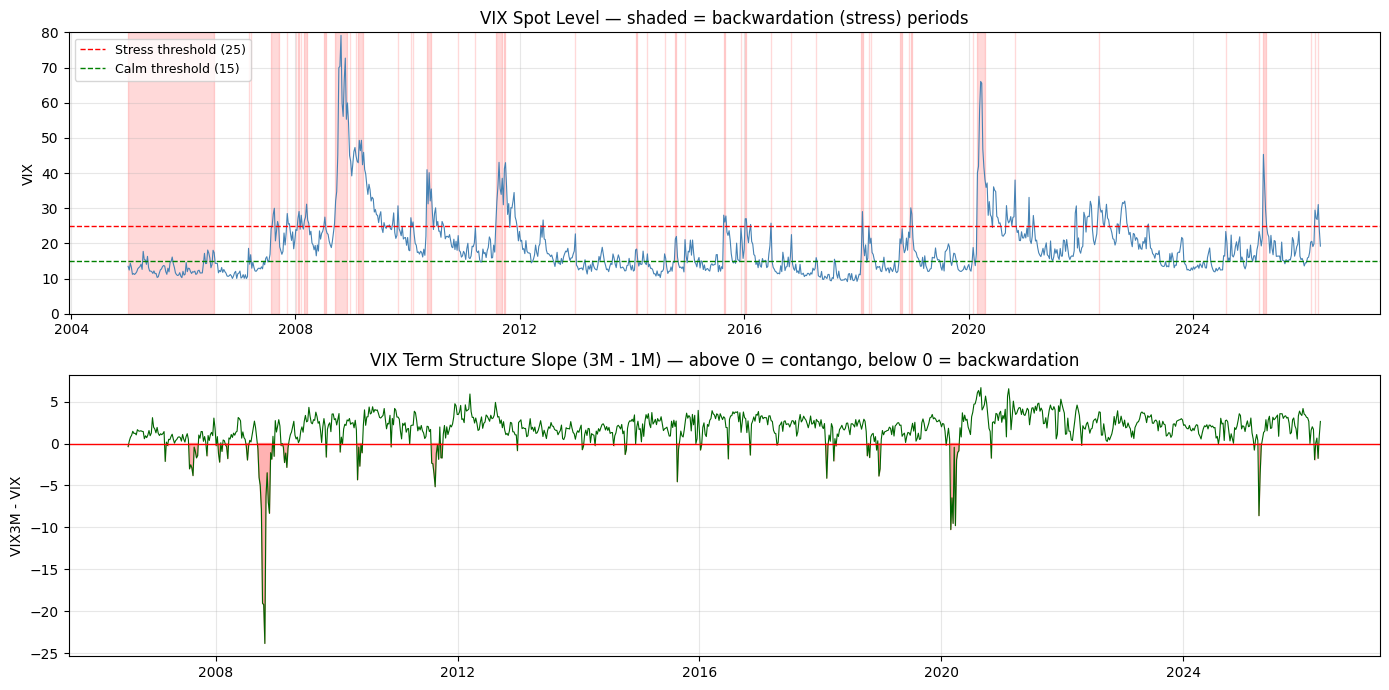

In [31]:
# ── VIX term structure chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# VIX level with stress zones
axes[0].plot(vix_weekly.index, vix_weekly["VIX"], color="steelblue", linewidth=0.8)
axes[0].set_title("VIX Spot Level — shaded = backwardation (stress) periods")
if not vix_weekly["VIX"].isna().all():
    axes[0].axhline(25, color="red", linewidth=1, linestyle="--", label="Stress threshold (25)")
    axes[0].axhline(15, color="green", linewidth=1, linestyle="--", label="Calm threshold (15)")
    stress_mask = (vix_weekly["contango"] == 0).fillna(False).values
    axes[0].fill_between(
        vix_weekly.index, np.zeros(len(vix_weekly)), np.repeat(80.0, len(vix_weekly)),
        where=stress_mask, alpha=0.15, color="red"
    )
    axes[0].set_ylim(0, 80)
    axes[0].legend(fontsize=9)
    axes[0].set_ylabel("VIX")

# Term structure slope
if "slope_1m_3m" in vix_weekly.columns:
    slope = pd.to_numeric(vix_weekly["slope_1m_3m"], errors="coerce")
    axes[1].plot(vix_weekly.index, slope, color="darkgreen", linewidth=0.8)
    axes[1].set_title("VIX Term Structure Slope (3M - 1M) — above 0 = contango, below 0 = backwardation")
    axes[1].axhline(0, color="red", linewidth=1)
    axes[1].fill_between(
        vix_weekly.index, slope.values, np.zeros(len(slope)),
        where=(slope.values < 0), alpha=0.3, color="red"
    )
    axes[1].set_ylabel("VIX3M - VIX")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "01_vix_term_structure.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Google Trends — free fear/sentiment signal

### What this section is doing
Downloads weekly Google search volume for recession/stress-related keywords using `pytrends`.
This is a **free alternative data source** that most institutional funds ignore because
the signal is too small at very large AUM — but at our scale it can still be useful as a regime feature.

### Why this works
Search activity around recession and crash-related topics can lead visible market stress by a short window.
The signal is noisy, so we treat it as a conditioning feature, not a headline alpha.

### Reproducibility upgrade
This notebook now saves:

- a raw keyword snapshot before normalization
- pull metadata with timestamp and keyword list
- slower request pacing plus simple retry/backoff settings to reduce transient rate-limit failures

That makes the downstream fear feature easier to audit and less dependent on re-querying Google every time.


In [32]:
# ── Download Google Trends for fear/sentiment keywords ───────────────────────
# Hardening note: slower pacing plus a small retry/backoff loop reduces transient rate-limit failures.

TREND_KEYWORDS = [
    "recession",
    "stock market crash",
    "inflation",
    "bear market",
]

GOOGLE_TRENDS_REQUEST_PAUSE_SECONDS = 8
GOOGLE_TRENDS_MAX_RETRIES = 3
GOOGLE_TRENDS_BACKOFF_SECONDS = 10

# Google Trends works best fetched one keyword at a time
def fetch_google_trends(
    keywords,
    start_year=2005,
    request_pause_seconds=GOOGLE_TRENDS_REQUEST_PAUSE_SECONDS,
    max_retries=GOOGLE_TRENDS_MAX_RETRIES,
    backoff_seconds=GOOGLE_TRENDS_BACKOFF_SECONDS,
):
    """Fetch Google Trends data with modest retry and backoff handling."""
    if TrendReq is None:
        raise ImportError("pytrends not installed")

    frames = []
    timeframe = f"{start_year}-01-01 {datetime.today().strftime('%Y-%m-%d')}"

    for kw in keywords:
        for attempt in range(1, max_retries + 1):
            try:
                pytrends = TrendReq(hl="en-US", tz=360, timeout=(10, 25))
                pytrends.build_payload([kw], cat=0, timeframe=timeframe, geo="US")
                df = pytrends.interest_over_time()

                if not df.empty and kw in df.columns:
                    s = ensure_series(df[kw], name=kw).resample("W-FRI").mean()
                    frames.append(s)
                    print(f"  '{kw}': {s.notna().sum()} weeks  (latest: {s.dropna().index.max().date()})")
                else:
                    print(f"  '{kw}': no usable data")
                break
            except Exception as e:
                if attempt == max_retries:
                    print(f"  '{kw}': FAILED after {max_retries} attempts — {e}")
                else:
                    wait_seconds = request_pause_seconds + backoff_seconds * attempt
                    print(f"  '{kw}': retrying with attempt {attempt + 1}/{max_retries} in {wait_seconds}s — {e}")
                    time.sleep(wait_seconds)

        time.sleep(request_pause_seconds)

    if len(frames) == 0:
        return pd.DataFrame()
    return pd.concat(frames, axis=1)

print("Fetching Google Trends (this may take 1-3 minutes because requests are paced to avoid rate limits)...")
trends_pull_meta = {
    "pull_timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "keywords": TREND_KEYWORDS,
    "geo": "US",
    "source": "pytrends",
    "status": "not_run",
    "request_pause_seconds": GOOGLE_TRENDS_REQUEST_PAUSE_SECONDS,
    "max_retries_per_keyword": GOOGLE_TRENDS_MAX_RETRIES,
    "backoff_seconds": GOOGLE_TRENDS_BACKOFF_SECONDS,
}

try:
    trends_df = fetch_google_trends(TREND_KEYWORDS)
    if trends_df.empty:
        raise ValueError("No Google Trends data returned")

    trends_df = flatten_columns(trends_df)
    trends_df.to_csv(PROCESSED_DIR / "google_trends_raw.csv")

    # Resample to weekly Friday (Trends is already weekly but may not align to Friday)
    trends_weekly = trends_df.resample("W-FRI").last()
    trends_weekly = trends_weekly.reindex(weekly_prices.index)
    trends_weekly = trends_weekly.ffill(limit=2)

    # Normalize each series to a rolling z-score
    for col in list(trends_weekly.columns):
        roll_mean = trends_weekly[col].rolling(104, min_periods=52).mean()
        roll_std  = trends_weekly[col].rolling(104, min_periods=52).std()
        trends_weekly[f"{col}_zscore"] = (trends_weekly[col] - roll_mean) / (roll_std + 1e-8)

    # Create composite fear index
    raw_cols = [c for c in trends_weekly.columns if "_zscore" not in c]
    trends_weekly["fear_composite"] = trends_weekly[raw_cols].mean(axis=1)
    roll_m = trends_weekly["fear_composite"].rolling(104, min_periods=52).mean()
    roll_s = trends_weekly["fear_composite"].rolling(104, min_periods=52).std()
    trends_weekly["fear_composite_zscore"] = (trends_weekly["fear_composite"] - roll_m) / (roll_s + 1e-8)
    trends_weekly = flatten_columns(trends_weekly)

    print(f"\nGoogle Trends shape: {trends_weekly.shape}")
    print("Columns:", list(trends_weekly.columns))

    trends_path = PROCESSED_DIR / "google_trends.csv"
    trends_weekly.to_csv(trends_path)
    print(f"\nSaved: {trends_path}")

    trends_pull_meta["status"] = "success"

except Exception as e:
    print(f"Google Trends download failed: {e}")
    print("Saving empty placeholder — re-run this cell when rate limits or transient network errors clear.")
    trends_weekly = pd.DataFrame(index=weekly_prices.index, columns=["fear_composite", "fear_composite_zscore"])
    trends_weekly.index.name = "Date"
    trends_weekly.to_csv(PROCESSED_DIR / "google_trends.csv")
    pd.DataFrame(columns=TREND_KEYWORDS).to_csv(PROCESSED_DIR / "google_trends_raw.csv", index=False)
    trends_pull_meta["status"] = "failed"
    trends_pull_meta["error"] = str(e)

with open(PROCESSED_DIR / "google_trends_snapshot_meta.json", "w") as f:
    json.dump(trends_pull_meta, f, indent=2)
print(f"Saved raw Google Trends snapshot: {PROCESSED_DIR / 'google_trends_raw.csv'}")
print(f"Saved Google Trends metadata: {PROCESSED_DIR / 'google_trends_snapshot_meta.json'}")


Fetching Google Trends (this may take 30-60 seconds due to rate limiting)...
  'recession': 256 weeks  (latest: 2026-04-03)
  'stock market crash': 256 weeks  (latest: 2026-04-03)
  'inflation': 256 weeks  (latest: 2026-04-03)
  'bear market': 256 weeks  (latest: 2026-04-03)

Google Trends shape: (1110, 10)
Columns: ['recession', 'stock market crash', 'inflation', 'bear market', 'recession_zscore', 'stock market crash_zscore', 'inflation_zscore', 'bear market_zscore', 'fear_composite', 'fear_composite_zscore']

Saved: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data2/processed/google_trends.csv


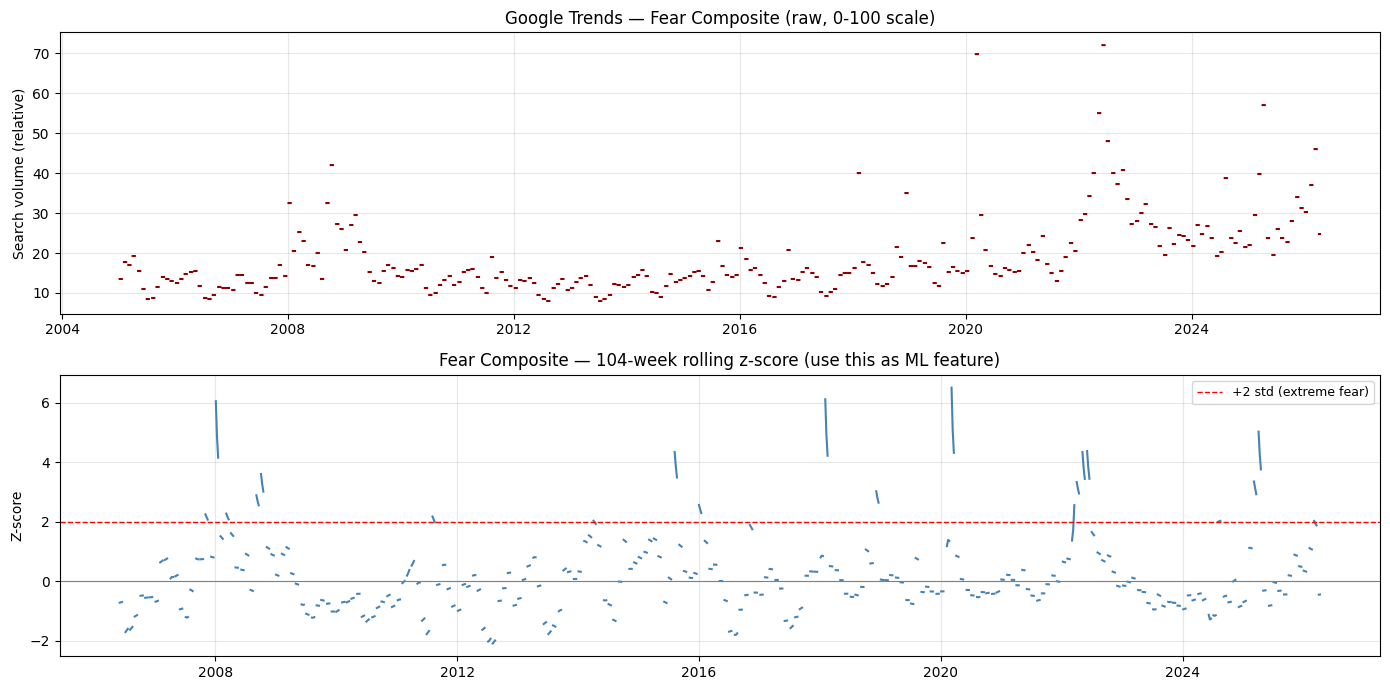

In [33]:
# ── Google Trends visualization ───────────────────────────────────────────────
if "fear_composite" in trends_weekly.columns and not trends_weekly["fear_composite"].isna().all():
    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    axes[0].plot(trends_weekly.index, trends_weekly["fear_composite"], color="darkred")
    axes[0].set_title("Google Trends — Fear Composite (raw, 0-100 scale)")
    axes[0].set_ylabel("Search volume (relative)")

    if "fear_composite_zscore" in trends_weekly.columns:
        axes[1].plot(trends_weekly.index, trends_weekly["fear_composite_zscore"], color="steelblue")
        axes[1].set_title("Fear Composite — 104-week rolling z-score (use this as ML feature)")
        axes[1].axhline(0, color="gray", linewidth=0.8)
        axes[1].axhline(2, color="red", linewidth=1, linestyle="--", label="+2 std (extreme fear)")
        axes[1].legend(fontsize=9)
        axes[1].set_ylabel("Z-score")

    plt.tight_layout()
    plt.savefig(PROCESSED_DIR / "01_google_trends.png", dpi=120, bbox_inches="tight")
    plt.show()


## 8. Data quality report

### What this section is doing
Generates a comprehensive quality report for every ETF in the universe.
This documents exactly which ETFs have full history and which have shorter histories,
so downstream notebooks can handle them correctly.

### Why this matters
Using an ETF in a signal calculation before its actual inception date would introduce
survivorship bias — we would only include it because we know it exists and performed well.
The quality report prevents this by documenting the true start date of each ETF.

### What downstream notebooks do with this
- Signal construction uses `skipna=False` and masks signals before each ETF's start date
- The optimizer uses only ETFs with at least 52 weeks of history at each rebalancing date
- The walk-forward validation respects these dates in the expanding universe logic


In [34]:
# ── Build data quality report ─────────────────────────────────────────────────
quality_records = []

for ticker in weekly_prices.columns:
    series = weekly_prices[ticker].dropna()

    if len(series) == 0:
        quality_records.append({
            "Ticker": ticker,
            "Description": UNIVERSE.get(ticker, "Unknown"),
            "Asset Class": UNIVERSE_ASSET_CLASS.get(ticker, "Unknown"),
            "Start Date": None,
            "End Date": None,
            "Weeks Available": 0,
            "Weeks Missing": len(weekly_prices),
            "Completeness %": 0,
            "Has Full History": False,
            "Ann Vol %": None,
        })
        continue

    n_available = len(series)
    n_total     = len(weekly_prices)
    n_missing   = n_total - n_available

    # Annualized vol
    rets    = np.log(series / series.shift(1)).dropna()
    ann_vol = rets.std() * np.sqrt(52) * 100

    quality_records.append({
        "Ticker": ticker,
        "Description": UNIVERSE.get(ticker, "Unknown"),
        "Asset Class": UNIVERSE_ASSET_CLASS.get(ticker, "Unknown"),
        "Start Date": series.index.min().date(),
        "End Date": series.index.max().date(),
        "Weeks Available": int(n_available),
        "Weeks Missing": int(n_missing),
        "Completeness %": round(n_available / n_total * 100, 1),
        "Has Full History": bool(n_missing <= 10),
        "Ann Vol %": round(ann_vol, 1),
    })

quality_df = pd.DataFrame(quality_records).set_index("Ticker")
quality_df = quality_df.sort_values("Weeks Available", ascending=False)

print("DATA QUALITY REPORT")
print("=" * 80)
print(quality_df[["Description", "Asset Class", "Start Date", "Weeks Available", "Completeness %",
                  "Has Full History", "Ann Vol %"]].to_string())

quality_path = PROCESSED_DIR / "data_quality_report.csv"
quality_df.to_csv(quality_path)
print(f"\nSaved: {quality_path}")


DATA QUALITY REPORT
                                Description  Start Date  Weeks Available  Completeness %  Has Full History  Ann Vol %
Ticker                                                                                                               
TIP           TIPS (Inflation-Linked Bonds)  2005-01-07             1110           100.0              True        6.0
SPY                  US Large Cap (S&P 500)  2005-01-07             1110           100.0              True       17.7
XLV                              Healthcare  2005-01-07             1110           100.0              True       16.3
XLU                               Utilities  2005-01-07             1110           100.0              True       18.1
XLP                        Consumer Staples  2005-01-07             1110           100.0              True       13.3
XLK                              Technology  2005-01-07             1110           100.0              True       20.3
XLI                             Indu

In [35]:
# ── Universe subsets and benchmark / proxy files for downstream use ──────────
# Core universe: ETFs with at least 10 years of history (~520 weeks)
CORE_UNIVERSE = quality_df[quality_df["Weeks Available"] >= 520].index.tolist()

# Full universe: all ETFs with at least 3 years of history
FULL_UNIVERSE = quality_df[quality_df["Weeks Available"] >= 156].index.tolist()

print(f"Core universe (10+ years): {len(CORE_UNIVERSE)} ETFs")
print(CORE_UNIVERSE)
print()
print(f"Full universe (3+ years): {len(FULL_UNIVERSE)} ETFs")
print(FULL_UNIVERSE)

universe_metadata = (
    quality_df.reset_index()
    .rename(columns={"Ticker": "ticker", "Description": "description", "Asset Class": "asset_class"})
)
universe_metadata["in_core_universe"] = universe_metadata["ticker"].isin(CORE_UNIVERSE)
universe_metadata["in_full_universe"] = universe_metadata["ticker"].isin(FULL_UNIVERSE)
universe_metadata_path = PROCESSED_DIR / "universe_metadata.csv"
universe_metadata.to_csv(universe_metadata_path, index=False)

# Save universe definitions for downstream notebooks
universe_def = {
    "core": CORE_UNIVERSE,
    "full": FULL_UNIVERSE,
    "all":  list(weekly_prices.columns),
    "descriptions": UNIVERSE,
    "asset_class_map": UNIVERSE_ASSET_CLASS,
    "proxy_mapping": PROXY_MAPPING,
}
with open(PROCESSED_DIR / "universe.json", "w") as f:
    json.dump(universe_def, f, indent=2)
print(f"\nSaved universe definitions: {PROCESSED_DIR / 'universe.json'}")
print(f"Saved universe metadata: {universe_metadata_path}")

benchmark_rows = []
benchmark_tickers = []
for role, info in PROXY_MAPPING.items():
    ticker = info["ticker"]
    benchmark_rows.append(
        {
            "proxy_role": role,
            "ticker": ticker,
            "description": info["description"],
            "available_in_universe": ticker in weekly_prices.columns,
        }
    )
    if ticker in weekly_prices.columns:
        benchmark_tickers.append(ticker)

benchmarks_df = pd.DataFrame(benchmark_rows)
benchmarks_path = PROCESSED_DIR / "benchmarks.csv"
benchmarks_df.to_csv(benchmarks_path, index=False)
with open(PROCESSED_DIR / "proxy_mapping.json", "w") as f:
    json.dump(PROXY_MAPPING, f, indent=2)

benchmark_tickers = sorted(set(benchmark_tickers))
benchmark_prices_weekly = weekly_prices[benchmark_tickers].copy()
benchmark_returns_weekly = weekly_returns[benchmark_tickers].copy()
benchmark_prices_weekly.to_csv(PROCESSED_DIR / "benchmark_prices_weekly.csv")
benchmark_returns_weekly.to_csv(PROCESSED_DIR / "benchmark_returns_weekly.csv")

print(f"Saved benchmark table: {benchmarks_path}")
print(f"Saved proxy mapping: {PROCESSED_DIR / 'proxy_mapping.json'}")
print(f"Saved benchmark weekly prices: {PROCESSED_DIR / 'benchmark_prices_weekly.csv'}")
market_proxy_ticker = PROXY_MAPPING.get("market_proxy", {}).get("ticker", "SPY")
if market_proxy_ticker in weekly_prices.columns and market_proxy_ticker in weekly_returns.columns:
    market_proxy_weekly = pd.DataFrame(
        {
            "market_proxy_price": weekly_prices[market_proxy_ticker],
            "market_proxy_log_return": weekly_returns[market_proxy_ticker],
        }
    )
    market_proxy_weekly.to_csv(PROCESSED_DIR / "market_proxy_weekly.csv")

print(f"Saved benchmark weekly returns: {PROCESSED_DIR / 'benchmark_returns_weekly.csv'}")
if market_proxy_ticker in weekly_prices.columns and market_proxy_ticker in weekly_returns.columns:
    print(f"Saved market proxy weekly file: {PROCESSED_DIR / 'market_proxy_weekly.csv'}")

# Hygiene note: downstream rebalancing logic should gate on available return history
# rather than automatically treating the very first weekly row as a valid rebalance date.
research_calendar = pd.DataFrame(index=weekly_prices.index)
research_calendar.index.name = "Date"
research_calendar["history_weeks_available"] = np.arange(len(research_calendar), dtype=int)
for lookback in [13, 26, 52, 104]:
    research_calendar[f"ready_for_{lookback}w_lookback"] = research_calendar["history_weeks_available"] >= lookback
research_calendar_path = PROCESSED_DIR / "research_calendar.csv"
research_calendar.to_csv(research_calendar_path)
print(f"Saved research calendar: {research_calendar_path}")


Core universe (10+ years): 35 ETFs
['TIP', 'SPY', 'XLV', 'XLU', 'XLP', 'XLK', 'XLI', 'XLF', 'XLE', 'XLB', 'VUG', 'VTV', 'VNQ', 'TLT', 'XLY', 'IEF', 'EEM', 'QQQ', 'EFA', 'EWJ', 'GLD', 'LQD', 'SHY', 'IWM', 'IAU', 'VWO', 'USO', 'SLV', 'DBA', 'UUP', 'MBB', 'HYG', 'BIL', 'VEA', 'PDBC']

Full universe (3+ years): 35 ETFs
['TIP', 'SPY', 'XLV', 'XLU', 'XLP', 'XLK', 'XLI', 'XLF', 'XLE', 'XLB', 'VUG', 'VTV', 'VNQ', 'TLT', 'XLY', 'IEF', 'EEM', 'QQQ', 'EFA', 'EWJ', 'GLD', 'LQD', 'SHY', 'IWM', 'IAU', 'VWO', 'USO', 'SLV', 'DBA', 'UUP', 'MBB', 'HYG', 'BIL', 'VEA', 'PDBC']

Saved universe definitions: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data2/processed/universe.json


## 8A. Cached Yahoo snapshots for downstream reproducibility

### What this section is doing
Saves two lightweight cached artifacts that make Layer 1 signal research more reproducible:

- a Yahoo metadata snapshot with pull timestamp
- ETF distribution history as exposed by Yahoo at pull time

### Why this matters
Carry is the weakest part of the ETF signal stack because true carry is not directly available.
Caching the metadata and distribution history does **not** solve that problem, but it does stop later notebooks
from relying entirely on live point-in-time queries.


In [ ]:
# ── Cache Yahoo metadata and ETF distribution history snapshots ───────────────
metadata_records = []
distribution_records = []

for ticker in TICKERS:
    metadata = safe_ticker_info(ticker)
    metadata["asset_class"] = UNIVERSE_ASSET_CLASS.get(ticker, "Unknown")
    metadata["description"] = UNIVERSE.get(ticker, "Unknown")
    metadata_records.append(metadata)

    dividends = safe_dividend_history(ticker)
    if not dividends.empty:
        for dt, amount in dividends.items():
            distribution_records.append(
                {
                    "Date": pd.Timestamp(dt).strftime("%Y-%m-%d"),
                    "ticker": ticker,
                    "distribution": float(amount),
                    "pull_timestamp_utc": metadata["pull_timestamp_utc"],
                    "source": "yfinance.dividends",
                }
            )

    time.sleep(0.1)

yahoo_metadata_snapshot = pd.DataFrame(metadata_records)
yahoo_metadata_path = PROCESSED_DIR / "yahoo_metadata_snapshot.csv"
yahoo_metadata_snapshot.to_csv(yahoo_metadata_path, index=False)

etf_distribution_history = pd.DataFrame(distribution_records)
if etf_distribution_history.empty:
    etf_distribution_history = pd.DataFrame(
        columns=["Date", "ticker", "distribution", "pull_timestamp_utc", "source"]
    )
distribution_history_path = PROCESSED_DIR / "etf_distribution_history.csv"
etf_distribution_history.to_csv(distribution_history_path, index=False)

print(f"Saved Yahoo metadata snapshot: {yahoo_metadata_path}")
print(f"Saved ETF distribution history snapshot: {distribution_history_path}")


## 9. Summary and what comes next

### What this notebook accomplished

| Dataset | File | Notes |
|---|---|---|
| Daily prices | `daily_prices.csv` | Raw adjusted-close history |
| Daily returns | `daily_returns.csv` | Useful for beta, vol, downside, and later microstructure-adjacent work |
| Weekly prices | `weekly_prices.csv` | Primary weekly price panel |
| Weekly returns | `weekly_returns.csv` | Primary weekly log-return panel |
| FRED macro | `macro_weekly.csv` | Regime conditioning and liquidity proxies |
| VIX term structure | `vix_term_structure.csv` | Market stress / vol-carry context |
| Google Trends | `google_trends.csv` | Normalized fear / sentiment feature |
| Google Trends raw snapshot | `google_trends_raw.csv` | Cached raw keyword pull for reproducibility |
| Research calendar | `research_calendar.csv` | Flags when there is enough weekly history for downstream lookback windows |
| Quality report | `data_quality_report.csv` | ETF history and completeness audit |
| Universe metadata | `universe.json`, `universe_metadata.csv` | Universe subsets plus asset-class labels |
| Benchmark / proxy files | `benchmarks.csv`, `proxy_mapping.json`, `benchmark_prices_weekly.csv`, `benchmark_returns_weekly.csv`, `market_proxy_weekly.csv` | Explicit market / cash / duration references |
| Yahoo snapshots | `yahoo_metadata_snapshot.csv`, `etf_distribution_history.csv` | Cached metadata for carry / audit work |

### What comes next: Notebook 02 — Layer 1 Alpha Signals

In the next notebook, we build and validate the Layer 1 signal library while:

1. enforcing an explicit timing convention and lag policy
2. validating signals with IC, decay, coverage, turnover, and cost sensitivity
3. adding cleaner downstream artifacts such as a signal manifest and redundancy analysis


In [36]:
# ── Final file inventory ──────────────────────────────────────────────────────
print("FILES CREATED BY THIS NOTEBOOK")
print("=" * 60)
for f in sorted(PROCESSED_DIR.glob("*.csv")) + sorted(PROCESSED_DIR.glob("*.json")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>7.1f} KB")

print()
print("NEXT: Run 02_layer1_alpha_signals.ipynb")


FILES CREATED BY THIS NOTEBOOK
  daily_prices.csv                               3275.5 KB
  data_quality_report.csv                           2.5 KB
  google_trends.csv                               102.5 KB
  macro_weekly.csv                                 55.1 KB
  vix_term_structure.csv                          106.7 KB
  weekly_prices.csv                               679.7 KB
  weekly_returns.csv                              786.9 KB
  universe.json                                     2.4 KB

NEXT: Run 02_signal_construction.ipynb
